In [71]:
from plot_configs_public import *

%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

The class `cases_myDNS_public` stores the parameters corresponding to the specified $Re_{\tau}$ and $Ri_{\tau}$. It includes methods for reading the input data files and computing derived quantities such as the heat flux, Obukhov length scale, coefficient of friction, and other relevant flow parameters.

In [72]:
class cases_myDNS_public:

    def __init__(self, file1, ReTau, RiTau, Pr, T1, T2):
        self.file1  = file1

        self.viscb = 1./ReTau
        self.ReTau = ReTau
        self.RiTau = RiTau
        self.Pr     = Pr
        self.T1     = T1
        self.T2     = T2
        self.vars   = vars

        self.DNS = None  
        self.scalars = {}  

    def read_data(self):

        self.DNS = pd.read_csv(self.file1)

    def compute(self):
        DNS        = self.DNS
        viscb      = 1./self.ReTau
        self.f1    = int(np.argmax(DNS['umc'].values) + 1)
        self.g     = self.RiTau/(1/self.T1 - 1/self.T2)

        if self.ReTau == 1000: ## the data is obtained from ZOnta. Hence treated differently

            self.uTau     = 1.
            self.qw       = viscb/self.Pr*(DNS['sc'].values[1]-DNS['sc'].values[0])/(DNS['zc'].values[1]-DNS['zc'].values[0])
            self.tauW     = -1.    
            self.u        = DNS['umc'].values[:self.f1]
            self.reyc     = self.ReTau
            self.ub       = np.sum(DNS['umc'].values*DNS['dzf'])/2


        if self.ReTau != 1000: ## Data from our simulations
            kth_c       = viscb/self.Pr*(2*DNS['kthc'].values[0]-DNS['kthf'].values[0])
            rho_c       = (2*DNS['rc'].values[0]-DNS['rf'].values[0])
            visc_c      = (2*DNS['muc'].values[0]-DNS['muf'].values[0]) / rho_c * viscb
            self.uTau   = np.sqrt( viscb*(2*DNS['tau13c'].values[0]-DNS['tau13f'].values[0])/rho_c)
            self.qw     = kth_c*(DNS['sc'].values[0]-self.T1)*2/DNS['dzc'].values[0]
            self.tauW   = rho_c*self.uTau**2
            self.u      = DNS['ruc'].values[:self.f1]/DNS['rc'].values[:self.f1]/self.uTau
            self.reyc   = self.uTau/visc_c*DNS['zc'].values[self.f1]
            self.ub     = np.sum(DNS['ruc'].values[:]/DNS['rc'].values[:]*DNS['dzf'].values)/2

        if self.g == 0:
            self.L    = float('inf')
        else:
            self.L    = 1./0.41/self.g/self.qw

        
        self.tauV = viscb*DNS['tau13c'].values[:self.f1]/self.tauW
        self.tauT = -DNS['ruwc'].values[:self.f1]/self.tauW
        self.zc   = DNS['zc'].values[:self.f1]
        self.zpc  = DNS['zp_c'].values[:self.f1]
        self.Cf   = 2*abs(self.tauW)/self.ub**2
        



In [73]:
def add_case_public(cases, ReTau, RiTau, f1):

    case = cases_myDNS_public(f1, ReTau, RiTau, Pr=0.71, T1=0.995, T2=1.005)

    case.read_data()

    case.compute()   
    cases[(int(ReTau), int(RiTau))] = case

    return cases

## Adding the DNS data to the cases dictionary

cases_[(ReTau, RiTau)] to access the specific case


### Variables 

vars_few = [
    `zc`, `zf`, `zp_c`, `rc`, `ruc`,
    `ruwc`, 
    `sc`, `umc`, `vmc`, `wmc`, `umf`, `vmf`, `wmf`,
    `muc`, `kthc`, `muf`, `kthf`, `rf`, `dzc`, `dzf`,
    `tau13c`, `tau13f`
]

In [74]:
cases_ = {}

Ritau1   = [0, 24, 60, 120, 240, 360, 480, 600, 720]
dir      =  'DNS_data/data395_'
files1   = [dir+'0.csv', dir+'24.csv', dir+'60.csv', dir+'120.csv', dir+'240.csv', dir+'360.csv', dir+'480.csv', dir+'600.csv', dir+'720.csv'] 

for i in range(len(Ritau1)):

    cases_ = add_case_public(cases_, 395., Ritau1[i], files1[i])

Ritau2  = [0, 60, 120, 240, 480, 720, 840, 900]
dir     =  'DNS_data/data550_'
files2  = [dir+'0.csv', dir+'60.csv', dir+'120.csv', dir+'240.csv', dir+'480.csv', dir+'720.csv', dir+'840.csv', dir+'900.csv']


for i in range(len(Ritau2)):

    cases_ = add_case_public(cases_, 550, Ritau2[i], files2[i])

base   =  'DNS_data/data1000_'
files3 = [base + '0.csv', base + '100.csv', base + '200.csv', base + '400.csv', base + '600.csv']
Retau3 = np.ones(len(files3))*1000
# Nu     = [28.15, 9.56, 6.81, 5.27, 4.64] 
Ritau3 = [ 0,  100, 200, 400, 600] 

for i in range(len(Ritau3)):

    cases_ = add_case_public(cases_, 1000., Ritau3[i], files3[i])



## Estimating the mean velocity profile

The mean velocity profile in stably stratified turbulent channel flows is estimated as a function of the friction Reynolds ($Re_{\tau}$) and the friction Richardson number ($Ri_{\tau}$). The composite profile is comprised of 5 distinct regions:

I.  Viscous sublayer: $u^+ = z^+$ 

II. Inertial sublayer: $u^+ = \frac{1}{\kappa} \ln(z^+) + \frac{4.7}{\kappa} \frac{2h}{L} \left(1 - \frac{z}{h}\right)^{-1/2} + C_1$

III. Stratified outer layer: $u^+ = \frac{1}{\kappa}\ln{\frac{z}{h}}-\frac{4.7}{\kappa} \frac{h}{L} \ln{\left(1 - \frac{z}{h}\right)} + \frac{2}{\kappa} \sqrt{1 - \frac{z}{h}} - \frac{2}{\kappa} \ln{\left(1 + \sqrt{1 - \frac{z}{h}}\right)} + C_2$

IV. Turbulent-viscous transition layer: Blending the profile III and V

V. Viscous core: $u_{\mathrm{cl}}^+ - u^+ = \frac{Re_{\tau}}{2}\left(1 - \frac{z}{h}\right)^2$

The constants are:

$C1 = {z_\mathrm{M}^+} - \frac{1}{\kappa}\ln({z_\mathrm{M}^+}) - \frac{4.7}{\kappa} \frac{2h}{L} - \frac{4.7}{\kappa} \frac{h}{L}\frac{{z_\mathrm{M}^+}}{Re_{\tau}} $ where, ${z_\mathrm{M}^+} = 11.1 + C_z \ \mathrm{max}\left(0, \frac{Ri_{\tau}}{Re_{\tau}} - 0.5\right)$

$ C2 \approx 1/\kappa \ln{Re_{\tau}} + 5.2$

## Obukhov length scale

For estimating the Obukhov length scale, $L$, we use the relation

$\frac{h}{L} = 0.115 \frac{1}{Pr}\left(\frac{Ri_{\tau}}{\sqrt{Re_{\tau}}}\right)^{2/3}$

In [75]:
class MOST_Ch:

    def __init__(self, ReTau, RiTau):
        
        self.ReTau = ReTau
        self.RiTau = RiTau

        self.L     = (.115*(self.RiTau/self.ReTau**(1./2.))**(2./3.))**(-1)
        self.u_cl  = 1/.41*np.log(self.ReTau) + 5.2 + .4*self.RiTau**(.65)
        self.u_cl  = 1/.41*np.log(self.ReTau) + 5.2 + .86*(self.RiTau/self.ReTau**(1./6.))**(.64)

        coeff  = [1, (1./self.L)**2 - 3, 3, -1]
        coeff2 = [1, (1./(8*self.L))**2 - 3, 3, -1]
        roots  = np.roots(coeff)
        roots2 = np.roots(coeff2)

        self.int_c0 = 11.1 + 2.0*max(0., self.RiTau/self.ReTau - 0.5)

        for jj in range(len(roots)):

            if np.isreal(roots[jj]):
                self.zt  = np.real(roots[jj])
            if np.isreal(roots2[jj]):
                self.z3u = np.real(roots2[jj])
    
        self.z5l  = 1-np.sqrt(4.7*0.5/.41*1./self.ReTau/self.L)

    def uI(self, z):

        zp = z*self.ReTau

        return zp

    def uII(self, z):

        zp = z*self.ReTau

        c0_c0  = self.int_c0 - 1/.41*np.log(self.int_c0) - 9.4*1./0.41*1/self.L - 4.7*1./0.41*1/self.L*self.int_c0/self.ReTau

        return 1/0.41*(np.log(zp) + 9.4/self.L*(1- zp/self.ReTau)**(-1./2.)) + c0_c0
    
    def uIII(self, z):

        return 1/0.41*np.log(z) \
                - 4.7/0.41*1./self.L*(np.log(1-z)) \
                + 2./0.41*(1 -z)**(.5) \
                - 2./0.41*np.log(1 + (1 -z)**(.5)) \
                + 1/0.41*np.log(self.ReTau) \
                + 5.2
    
    def uV(self, z):

        return -1./2.*self.ReTau*(1 - z)**2 + self.u_cl
    
    def uIV(self, z):

        u3u = self.uIII(self.z3u)
        u5l = self.uV  (self.z5l)

        return u3u + (u5l - u3u) * (z - self.z3u) / (self.z5l - self.z3u)
    
    def composite_u(self, z = None, N = 500):

        if z is None:
            z  = np.linspace(0, 1., N)
                    
        u = np.zeros_like(z)

        # Piecewise
        mask1 = z <= self.int_c0/self.ReTau
        mask2 = (z > self.int_c0/self.ReTau) & (z <= self.zt)
        mask3 = (z > self.zt) & (z <= self.z3u)
        mask4 = (z > self.z3u) & (z <= self.z5l)
        mask5 = z > self.z5l

        u[mask1] = self.uI(z[mask1])
        u[mask2] = self.uII(z[mask2])
        u[mask3] = self.uIII(z[mask3])
        u[mask4] = self.uIV(z[mask4])
        u[mask5] = self.uV(z[mask5])

        return z, u




/tmp/ipykernel_1783878/1980244001.py:40: RuntimeWarning: divide by zero encountered in power
  return 1/0.41*(np.log(zp) + 9.4/self.L*(1- zp/self.ReTau)**(-1./2.)) + c0_c0
/tmp/ipykernel_1783878/1980244001.py:45: RuntimeWarning: divide by zero encountered in log
  - 4.7/0.41*1./self.L*(np.log(1-z)) \


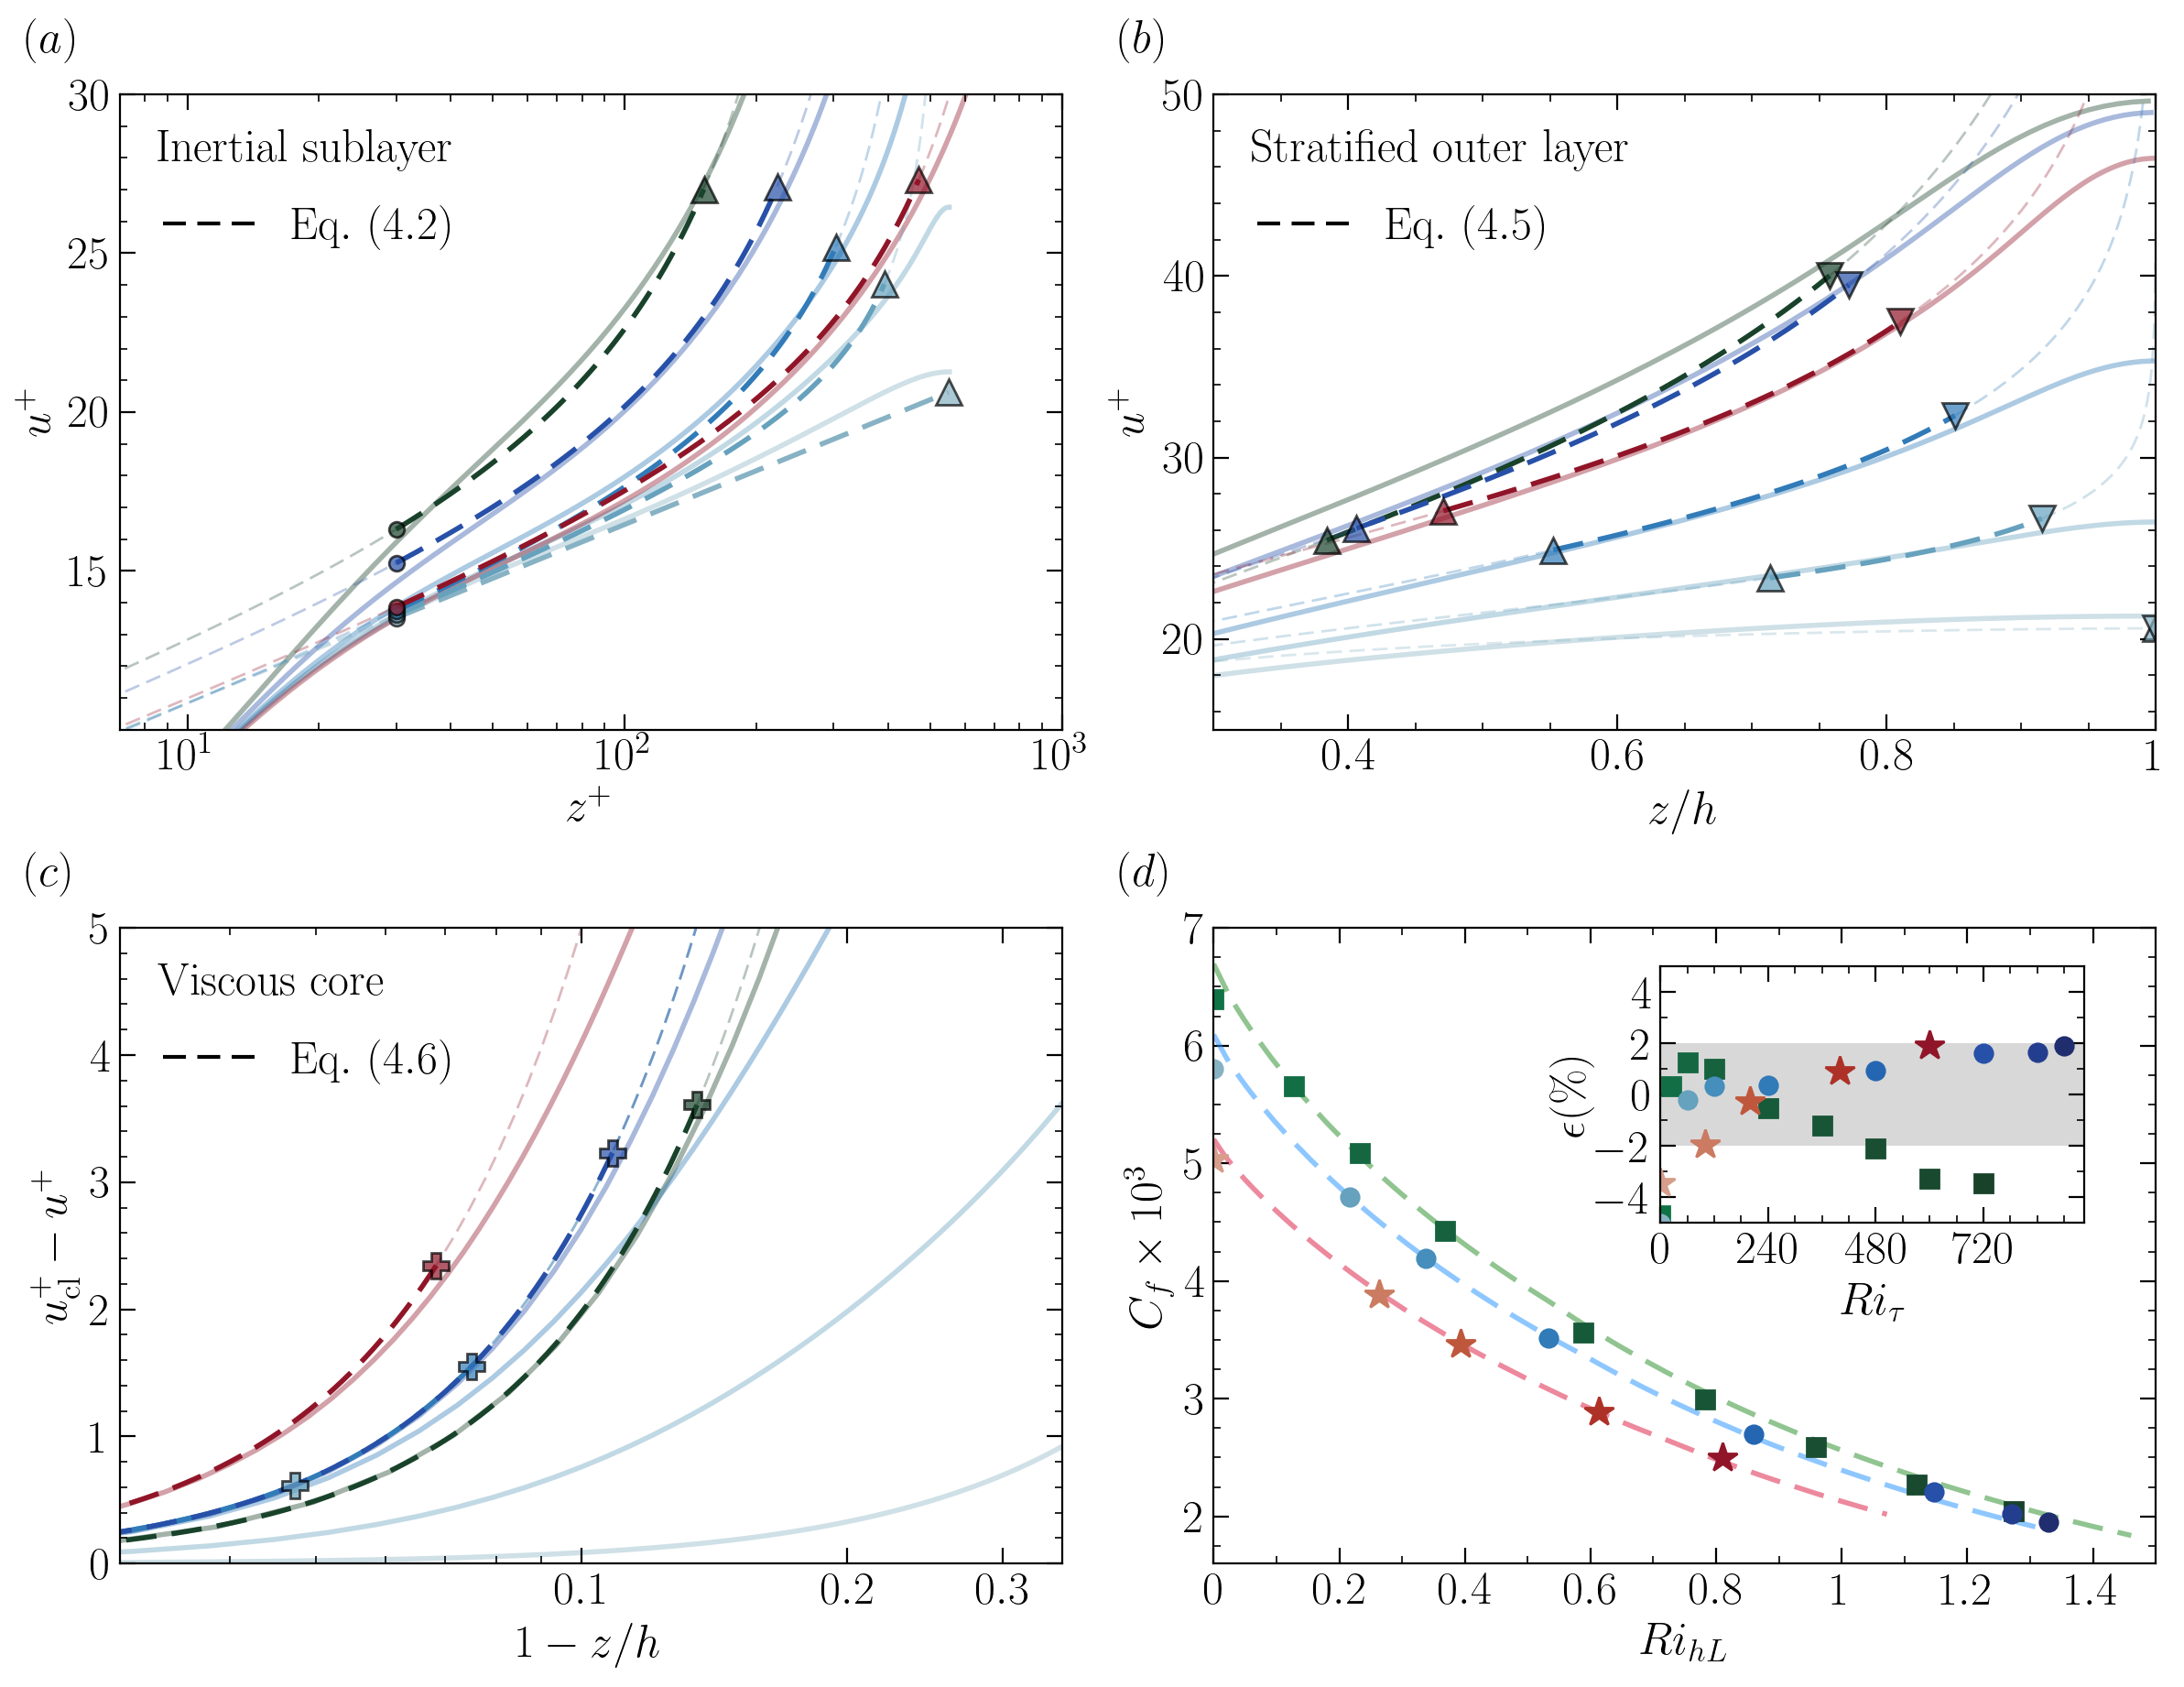

In [76]:
fig_u_comp, ((axs_reg_MO1, axs_regI_ii1), (axs_regII_i1, axs_Cf)) = plt.subplots(2,2)
fig_u_comp.set_figwidth(2*fig_width)
fig_u_comp.set_figheight(2.2*fig_height)

reT = [395, 550, 550, 550, 550, 1000]; riT = [720, 0, 60, 240, 720, 600]
clr_DNS = np.concatenate(([greens]*1, [blues]*4, [purples]*len(Ritau3)))
inc_DNS = [140, 40, 60, 100, 140, 160]

for i in range(len(reT)):

    if riT[i] == 0:
        vel_profile = MOST_Ch(reT[i], 1e-6)
    else:
        vel_profile = MOST_Ch(reT[i], riT[i])
    
    params = {'ls': '--', 'marker': '', 'color': clr_DNS[i](inc_DNS[i]), 'zorder': 1, 'dashes': (6, 3)}

    zp = np.linspace(0.0001, 30, 300);               axs_reg_MO1.semilogx(zp, vel_profile.uII(zp/reT[i]),         **params, alpha = 0.3, lw = 1) # MODEL 
    zp = np.linspace(30, vel_profile.zt*reT[i], 300);           axs_reg_MO1.semilogx(zp, vel_profile.uII(zp/reT[i]),         **params, alpha = 1.0, lw = 2) # MODEL 
    zp = np.linspace(vel_profile.zt*reT[i], reT[i], 300);     axs_reg_MO1.semilogx(zp, vel_profile.uII(zp/reT[i]),         **params, alpha = 0.3, lw = 1) # MODEL 
    axs_reg_MO1.semilogx(30, vel_profile.uII(30/reT[i]), marker = 'o', ms = 6, mfc = clr_DNS[i](inc_DNS[i]), mec = 'k', color = clr_DNS[i](inc_DNS[i]), alpha = .7, zorder = 2)
    axs_reg_MO1.semilogx(vel_profile.zt*reT[i], vel_profile.uII(vel_profile.zt), marker = '^', ms = 10, mfc = clr_DNS[i](inc_DNS[i]), mec = 'k', color = clr_DNS[i](inc_DNS[i]), alpha = .7, zorder = 2)
    axs_reg_MO1.semilogx(cases_[(reT[i], riT[i])].zpc, cases_[(reT[i], riT[i])].u, linewidth = 2, color = clr_DNS[i](inc_DNS[i]), alpha = .4, zorder = -1)   # DNS

    z = np.linspace(0.0001, vel_profile.zt, 300);   axs_regI_ii1.plot(z, vel_profile.uIII(z), **params, alpha = 0.3, lw = 1) # MODEL 
    z = np.linspace(vel_profile.zt, vel_profile.z3u, 300);    axs_regI_ii1.plot(z, vel_profile.uIII(z), **params, alpha = 1.0, lw = 2) # MODEL  , label = r'$\mathrm{Eq.}~(4.5)$'
    z = np.linspace(vel_profile.z3u, 1, 300);      axs_regI_ii1.plot(z, vel_profile.uIII(z), **params, alpha = 0.3, lw = 1) # MODEL 
    axs_regI_ii1.plot(vel_profile.zt,   vel_profile.uIII(vel_profile.zt),   marker = '^', ms = 10, mfc = clr_DNS[i](inc_DNS[i]), mec = 'k', color = clr_DNS[i](inc_DNS[i]), alpha = .7)
    axs_regI_ii1.plot(vel_profile.z3u, vel_profile.uIII(vel_profile.z3u), marker = 'v', ms = 10, mfc = clr_DNS[i](inc_DNS[i]), mec = 'k', color = clr_DNS[i](inc_DNS[i]), alpha = .7)
    axs_regI_ii1.plot(cases_[(reT[i], riT[i])].zc, cases_[(reT[i], riT[i])].u, lw = 2, color = clr_DNS[i](inc_DNS[i]), alpha = .4, zorder = -1) # DNS 

    z = np.linspace(0.0001, vel_profile.z5l, 300); axs_regII_i1.semilogx(1-z, -vel_profile.uV(z) + vel_profile.u_cl, **params, alpha = 0.3, lw = 1)
    z = np.linspace(vel_profile.z5l, 1, 300);      axs_regII_i1.semilogx(1-z, -vel_profile.uV(z) + vel_profile.u_cl, **params, alpha = 1.0, lw = 2)
    axs_regII_i1.plot(1-vel_profile.z5l, -vel_profile.uV(vel_profile.z5l) + vel_profile.u_cl, marker = 'P', ms = 10, mfc = clr_DNS[i](inc_DNS[i]), mec = 'k', color = clr_DNS[i](inc_DNS[i]), alpha = .7)
    axs_regII_i1.semilogx((1-cases_[(reT[i], riT[i])].zc), np.max(cases_[(reT[i], riT[i])].u) - cases_[(reT[i], riT[i])].u, lw = 2, color = clr_DNS[i](inc_DNS[i]), alpha = .4, zorder = -1)


axs_reg_MO1.set_ylim(bottom = 10.0001, top = 30)
axs_reg_MO1.set_xlim(left = 7., right = 1e3)
axs_reg_MO1.set_xlabel(r'$z^+$')
axs_reg_MO1.set_ylabel(r'$ u^+$')

axs_regI_ii1.xaxis.set_major_formatter(FuncFormatter(custom_formatter))
axs_regI_ii1.set_ylim(bottom = 15, top = 50)
axs_regI_ii1.set_xlim(left = 0.3, right = 1)
axs_regI_ii1.set_xlabel(r'$z/h$')
axs_regI_ii1.set_ylabel(r'$u^+$')

axs_regII_i1.set_ylim(bottom = 0, top = 5)
axs_regII_i1.set_xlim(left = 3e-2, right = 35e-2)
axs_regII_i1.set_xlabel(r'$1-z/h$')
axs_regII_i1.set_ylabel(r'$ u_{\mathrm{cl}}^+ - u^+$')
axs_regII_i1.xaxis.set_major_formatter(FuncFormatter(custom_formatter))
axs_regII_i1.xaxis.set_major_locator(MultipleLocator(.1))

params = {'ls': '--', 'marker': '', 'color': 'k', 'zorder': 1, 'dashes': (6, 3)}

axs_regI_ii1.annotate(r'$\mathrm{Stratified\ outer\ layer}$',
                    xy=(0.65, 48), xycoords='data',
                    xytext=(0.04, 0.88), textcoords='axes fraction',
                    horizontalalignment='left', verticalalignment='bottom', color = 'k')
legend_elements = [
         Line2D([0], [0], label=r'$\mathrm{Eq.}~(4.5)$',   **params, alpha=1.)] 
axs_regI_ii1.legend(handles = legend_elements, ncols = 1, loc=0, bbox_to_anchor=(0.1, 0.37, 0.3, .52), handletextpad=0.8, handlelength=2, frameon = False)#,, bbox_to_anchor=(0.41, 0.3, 0.2, .52))#, shadow=False, frameon=False, fontsize = 14.5, markerscale = 0.75, edgecolor = 'grey', fancybox = False, handletextpad=0.)

axs_reg_MO1.annotate(r'$\mathrm{Inertial\ sublayer}$',
                xy=(10, 30), xycoords='data',
                xytext=(0.04, 0.88), textcoords='axes fraction',
                horizontalalignment='left', verticalalignment='bottom', color = 'k')
 
legend_elements = [
         Line2D([0], [0], label=r'$\mathrm{Eq.}~(4.2)$',   **params, alpha=1.)]
axs_reg_MO1.legend(handles = legend_elements, ncols = 1, loc=0, bbox_to_anchor=(0.1, 0.37, 0.3, .52), handletextpad=0.8, handlelength=2, frameon = False)#,, bbox_to_anchor=(0.41, 0.3, 0.2, .52))#, shadow=False, frameon=False, fontsize = 14.5, markerscale = 0.75, edgecolor = 'grey', fancybox = False, handletextpad=0.)

axs_regII_i1.annotate(r'$\mathrm{Viscous\ core}$',
                xy=(.1, 5), xycoords='data',
                xytext=(0.04, 0.88), textcoords='axes fraction',
                horizontalalignment='left', verticalalignment='bottom', color = 'k')
 
legend_elements = [
         Line2D([0], [0], label=r'$\mathrm{Eq.}~(4.6)$',   **params, alpha=1.)]
axs_regII_i1.legend(handles = legend_elements, ncols = 1, loc=0, bbox_to_anchor=(0.1, 0.37, 0.3, .52), handletextpad=0.8, handlelength=2, frameon = False)#,, bbox_to_anchor=(0.41, 0.3, 0.2, .52))#, shadow=False, frameon=False, fontsize = 14.5, markerscale = 0.75, edgecolor = 'grey', fancybox = False, handletextpad=0.)

axs_reg_MO1.text(-0.1, 1.12, r'$(a)$', transform=axs_reg_MO1.transAxes,
               fontsize=18, fontweight='light', va='top', ha='left')
axs_regI_ii1.text(-0.1, 1.12, r'$(b)$', transform=axs_regI_ii1.transAxes,
               fontsize=18, fontweight='light', va='top', ha='left')
axs_regII_i1.text(-0.1, 1.12, r'$(c)$', transform=axs_regII_i1.transAxes,
               fontsize=18, fontweight='light', va='top', ha='left')
axs_Cf.text(-0.1, 1.12, r'$(d)$', transform=axs_Cf.transAxes,
               fontsize=18, fontweight='light', va='top', ha='left')


axs_Cf_err = inset_axes(axs_Cf, width='100%', height=1.4, bbox_to_anchor=(0.45, 0.5, .45, .55), bbox_transform=axs_Cf.transAxes, loc="lower left")

reT = [395, 550, 1000]
clr = ['forestgreen', 'dodgerblue', 'crimson']

riT = np.linspace(1e-6, 900, 500)

Cf_MCh = np.ones(len(riT))
Ri_hL  = np.ones(len(riT))

for j in range(len(reT)):

    for i in range(len(riT)):

        vel_profile = MOST_Ch(reT[j], riT[i])
        z, u        = vel_profile.composite_u()
        
        Cf_MCh[i] = 2./(integrate.trapezoid(u, z))**2
        Ri_hL[i]  = 1./vel_profile.L

    axs_Cf.plot(Ri_hL, Cf_MCh*1e3, lw = 2, color = clr[j], ls = '--', dashes = (6,3), alpha = .5)

riT_DNS = np.concatenate((Ritau1, Ritau2, Ritau3))
reT_DNS = np.concatenate((np.ones(len(Ritau1))*395, np.ones(len(Ritau2))*550, Retau3))
mst_DNS = np.concatenate((['s']*len(Ritau1), ['o']*len(Ritau2), ['*']*len(Ritau3)))
clr_DNS = np.concatenate(([greens]*len(Ritau1), [blues]*len(Ritau2), [purples]*len(Ritau3)))
inc_DNS = np.concatenate((np.linspace(40,140,9).astype(int), np.linspace(40,180,8).astype(int), np.linspace(40,160,5).astype(int)))
mss_DNS = np.concatenate((np.ones(len(Ritau1))*5, np.ones(len(Ritau2))*5, np.ones(len(Ritau3))*10))

for i in range(len(riT_DNS)):

    if riT_DNS[i] == 0:
        vel_profile = MOST_Ch(reT_DNS[i], 1e-6)
    else:
        vel_profile = MOST_Ch(reT_DNS[i], riT_DNS[i])

    z, u        = vel_profile.composite_u()
    
    Cf_MCh = 2./(integrate.trapezoid(u, z))**2*1e3
    Cf_dns = cases_[(reT_DNS[i], riT_DNS[i])].Cf*1e3

    axs_Cf.plot(1./cases_[(reT_DNS[i], riT_DNS[i])].L, Cf_dns, ls = '', marker = mst_DNS[i], ms = mss_DNS[i]+2, markerfacecolor = clr_DNS[i](inc_DNS[i]), markeredgecolor = clr_DNS[i](inc_DNS[i]), alpha = 1)

    axs_Cf_err.plot(riT_DNS[i], (Cf_dns-Cf_MCh)/Cf_dns*100, ls = '', marker = mst_DNS[i], ms = mss_DNS[i]+2, markerfacecolor = clr_DNS[i](inc_DNS[i]), markeredgecolor = clr_DNS[i](inc_DNS[i]), alpha = 1)

    # print(reT_DNS[i], riT_DNS[i],cases_[(reT_DNS[i], riT_DNS[i])].L)
axs_Cf.set_xlabel(r'$Ri_{hL}$'); axs_Cf_err.set_xlabel(r'$Ri_{\tau}$')
axs_Cf.set_ylabel(r'$C_f \times 10^3$')
axs_Cf.set_xlim(left = 0, right = 1.5)
axs_Cf.set_ylim(bottom = 1.6, top = 7)
axs_Cf.yaxis.set_major_formatter(FuncFormatter(custom_formatter))
axs_Cf.xaxis.set_major_formatter(FuncFormatter(custom_formatter))
axs_Cf.yaxis.set_major_locator(MultipleLocator(1))
axs_Cf.yaxis.set_minor_locator(MultipleLocator(.25))
axs_Cf.xaxis.set_major_locator(MultipleLocator(.2))
axs_Cf.xaxis.set_minor_locator(MultipleLocator(.1))


axs_Cf_err.set_ylabel(r'$\epsilon(\%)$', labelpad=0)
axs_Cf_err.set_ylim(bottom = -5, top = 5)
axs_Cf_err.set_xlim(left = 0, right = axs_Cf_err.get_xlim()[1])
axs_Cf_err.yaxis.set_major_formatter(FuncFormatter(custom_formatter))
axs_Cf_err.xaxis.set_major_formatter(FuncFormatter(custom_formatter))
axs_Cf_err.yaxis.set_major_locator(MultipleLocator(2))
axs_Cf_err.yaxis.set_minor_locator(MultipleLocator(1))
axs_Cf_err.xaxis.set_major_locator(MultipleLocator(240))
axs_Cf_err.xaxis.set_minor_locator(MultipleLocator(60))

rect = patches.Rectangle((0, -2-0.005), 950, 4, linewidth=1., facecolor='grey', alpha = .3)
axs_Cf_err.add_patch(rect)


fig_u_comp.savefig('all_profs.pdf')
